In [1]:
!pip install numpy pandas scikit-learn matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
california = fetch_california_housing(as_frame=True)
df = california.frame
print("--- First 5 Rows of Dataset ---")
print(df[['MedInc', 'MedHouseVal']].head())

--- First 5 Rows of Dataset ---
   MedInc  MedHouseVal
0  8.3252        4.526
1  8.3014        3.585
2  7.2574        3.521
3  5.6431        3.413
4  3.8462        3.422


In [5]:
X = df[['MedInc']]        
y = df['MedHouseVal']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = model.predict(X_test)

In [9]:
print("\n--- Model Results ---")
print(f"Slope (Coefficient / m): {model.coef_[0]:.4f}")
print(f"Intercept (b):           {model.intercept_:.4f}")
print(f"Equation:                y = {model.coef_[0]:.4f} * X + {model.intercept_:.4f}")
print("-----------------------")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"R² Score (Accuracy):      {r2_score(y_test, y_pred):.4f}")


--- Model Results ---
Slope (Coefficient / m): 0.4193
Intercept (b):           0.4446
Equation:                y = 0.4193 * X + 0.4446
-----------------------
Mean Squared Error (MSE): 0.7091
R² Score (Accuracy):      0.4589


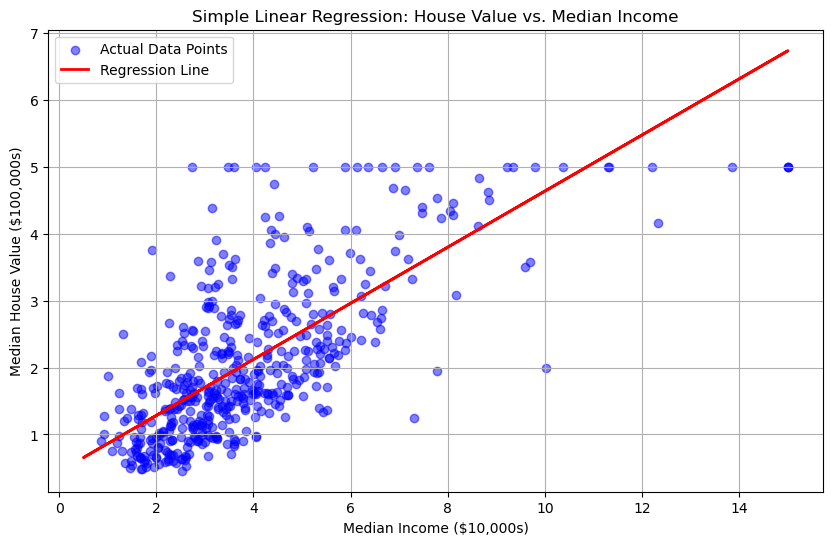

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:500], y_test[:500], color='blue', alpha=0.5, label='Actual Data Points')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: House Value vs. Median Income')
plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')
plt.legend()
plt.grid(True)
plt.show()